# Finding the best neighborhood in pittsburgh
### City of Pittsubrhg Trees Dataset from 2020

Sub metric: Number of trees, tree health, economic benefit
More trees in a neighborhood wouldn't nessesrilly mean a higher score unless they are all healthy. With trees in better health, there will be a better environment for residences to live in. More economic benefit from trees would mean residents would need to spend less on expenses such as their electricity bills for AC.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('trees.csv', low_memory=False)
print(f'{len(df):,} rows x {df.shape[1]} columns')
df[['neighborhood', 'common_name', 'condition', 'overall_benefits_dollar_value', 'latitude', 'longitude']].head(10)

45,709 rows x 59 columns


,neighborhood,common_name,condition,overall_benefits_dollar_value,latitude,longitude
0,Homewood North,Stump,NaN,NaN,40.458169,-79.889724
1,Oakwood,Linden: Littleleaf,NaN,125.178322,40.429269,-80.067868
2,South Side Flats,Maple: Red,Fair,77.767116,40.426797,-79.965035
3,East Allegheny,Maple: Freeman,Fair,81.838259,40.455503,-79.999276
4,Highland Park,Maple: Norway,Good,390.538994,40.476667,-79.924106
5,Highland Park,Oak: Pin,Good,206.575018,40.477496,-79.924568
6,Highland Park,Dogwood: Corneliancherry,Good,15.347590,40.478403,-79.925985
7,Highland Park,Maple: Norway,Good,115.787785,40.478404,-79.926126
8,Highland Park,Maple: Norway,Good,167.445388,40.478314,-79.926161
9,Stanton Heights,Maple: Norway,Poor,NaN,40.485240,-79.936390


## Removing trees that are missing data for neighborhood, health and overall benefits dollar value

In [7]:
df = df.dropna(subset=['neighborhood'])
df = df.dropna(subset=['condition'])
df = df.dropna(subset=['overall_benefits_dollar_value'])
print(f'{len(df):,} rows x {df.shape[1]} columns')
df[['neighborhood', 'common_name', 'condition', 'overall_benefits_dollar_value', 'latitude', 'longitude']].head(10)

39,854 rows x 59 columns


,neighborhood,common_name,condition,overall_benefits_dollar_value,latitude,longitude
2,South Side Flats,Maple: Red,Fair,77.767116,40.426797,-79.965035
3,East Allegheny,Maple: Freeman,Fair,81.838259,40.455503,-79.999276
4,Highland Park,Maple: Norway,Good,390.538994,40.476667,-79.924106
5,Highland Park,Oak: Pin,Good,206.575018,40.477496,-79.924568
6,Highland Park,Dogwood: Corneliancherry,Good,15.347590,40.478403,-79.925985
7,Highland Park,Maple: Norway,Good,115.787785,40.478404,-79.926126
8,Highland Park,Maple: Norway,Good,167.445388,40.478314,-79.926161
10,Sheraden,Honeylocust: Thornless,Good,254.376116,40.453213,-80.067245
11,Chartiers City,Oak: Northern Red,Good,366.156706,40.455997,-80.070408
12,Sheraden,Maple: Norway,Good,208.530326,40.453446,-80.070094


## Tree count graph

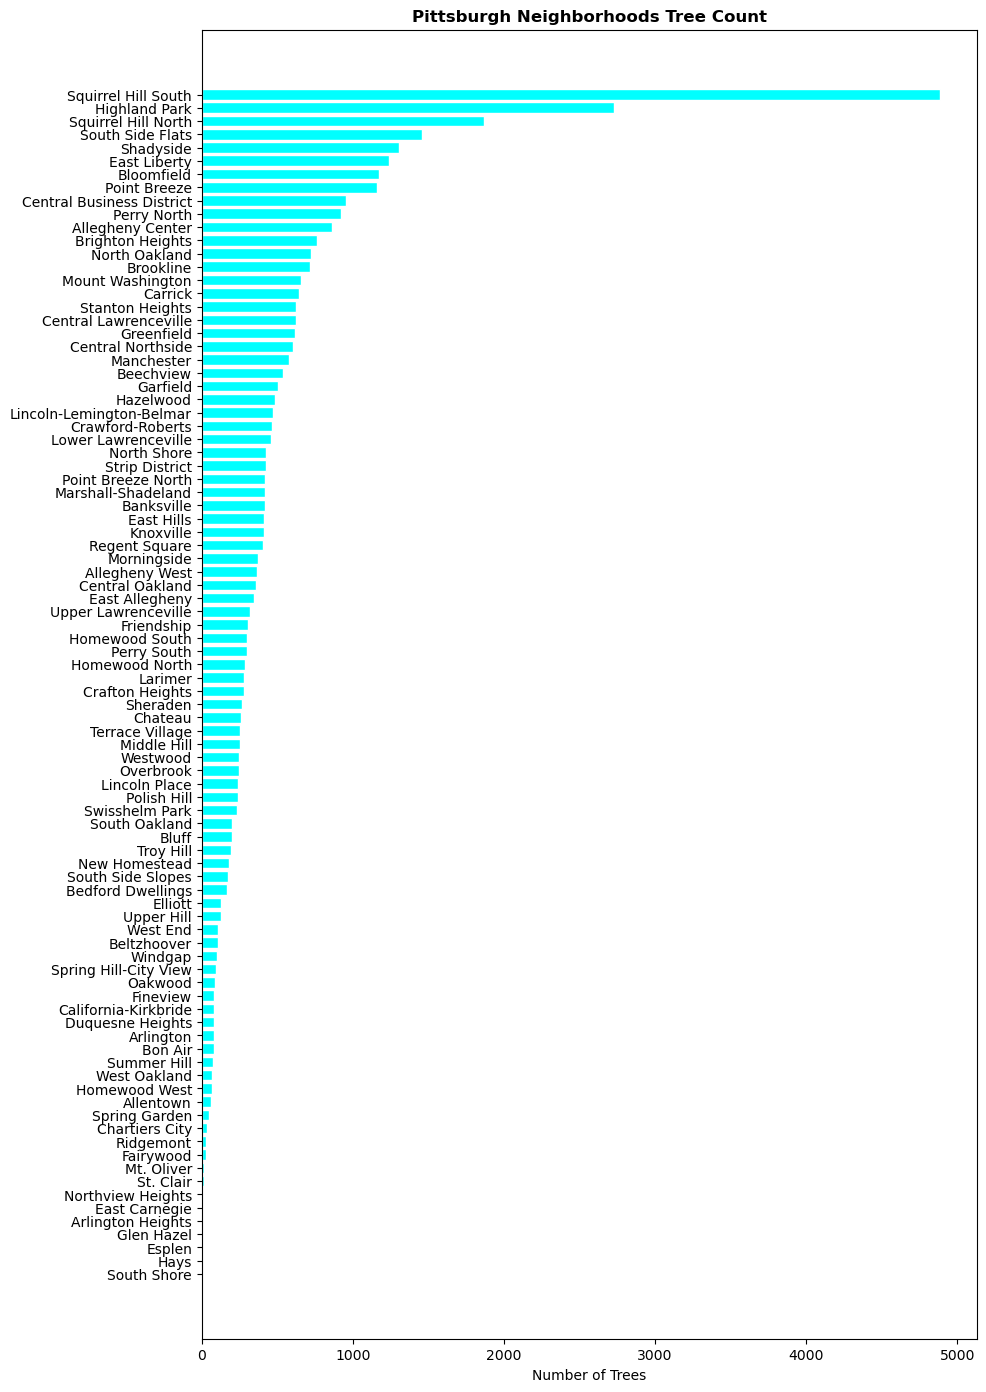

In [8]:
treecount = df.groupby('neighborhood').size().sort_values(ascending = False).sort_values()
fig, ax = plt.subplots(figsize=(10,17))
ax.barh(treecount.index, treecount.values, color = 'cyan', edgecolor = 'white')
ax.set_xlabel('Number of Trees')
ax.set_title('Pittsburgh Neighborhoods Tree Count', fontweight = 'bold')
plt.show()

## Weighing the tree health

Excluding trees that are not one of these five conditions excluding Dead, Critical, and Unknown as they dont bring much benefits to the neighborhood.
Then appying the weights to the trees and grouping them.

In [9]:
conditionWeights = {'Excellent': 1.0, 'Very Good': 0.9, 'Good': 0.75, 'Fair': 0.5, 'Poor': 0.25}
df_Weighed = df[df['condition'].isin(conditionWeights)].copy()
print("Trees with a weighted condition: " + str(len(df_Weighed)))

Trees with a weighted condition: 37797


In [10]:
df_Weighed['condition_weight'] = df_Weighed['condition'].map(conditionWeights)
df_Weighed.head(10)

,_id,id,address_number,street,common_name,scientific_name,height,width,growth_space_length,growth_space_width,...,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude,condition_weight
2,3,1431517397,2822,SIDNEY ST,Maple: Red,Acer rubrum,22.0,6.0,6.0,3.0,...,3.0,16.0,4.200316e+10,3.0,16.0,3.0,4-24,40.426797,-79.965035,0.50
3,4,994063598,608,SUISMON ST,Maple: Freeman,Acer x freemanii,25.0,10.0,3.0,3.0,...,1.0,23.0,4.200356e+10,1.0,23.0,1.0,1-6,40.455503,-79.999276,0.50
4,5,1591838573,1135,N NEGLEY AVE,Maple: Norway,Acer platanoides,52.0,13.0,99.0,99.0,...,7.0,11.0,4.200311e+10,2.0,11.0,5.0,3-9,40.476667,-79.924106,0.75
5,6,1333224197,5550,BRYANT ST,Oak: Pin,Quercus palustris,45.0,18.0,35.0,3.0,...,7.0,11.0,4.200311e+10,2.0,11.0,5.0,3-9,40.477496,-79.924568,0.75
6,7,239290336,5503,BRYANT ST,Dogwood: Corneliancherry,Cornus mas,8.0,4.0,99.0,3.0,...,7.0,11.0,4.200311e+10,2.0,11.0,5.0,3-9,40.478403,-79.925985,0.75
7,8,1233652274,1207,KING AVE,Maple: Norway,Acer platanoides,27.0,10.0,30.0,3.0,...,7.0,11.0,4.200311e+10,2.0,11.0,5.0,3-9,40.478404,-79.926126,0.75
8,9,1477030894,1201,KING AVE,Maple: Norway,Acer platanoides,35.0,12.0,3.0,3.0,...,7.0,11.0,4.200311e+10,2.0,11.0,5.0,3-9,40.478314,-79.926161,0.75
10,11,998993932,3233,THAYER ST,Honeylocust: Thornless,Gleditsia triacanthos inermis,48.0,20.0,99.0,99.0,...,2.0,20.0,4.200320e+10,5.0,20.0,6.0,1-16,40.453213,-80.067245,0.75
11,12,1870646392,1427,ISOLINE ST,Oak: Northern Red,Quercus rubra,65.0,20.0,99.0,99.0,...,2.0,20.0,4.200356e+10,5.0,20.0,6.0,1-16,40.455997,-80.070408,0.75
12,13,829500067,1400,EVANSTON ST,Maple: Norway,Acer platanoides,22.0,12.0,99.0,99.0,...,2.0,20.0,4.200320e+10,5.0,20.0,6.0,1-16,40.453446,-80.070094,0.75


In [11]:
health_score = (df_Weighed.groupby('neighborhood')['condition_weight'].sum().reset_index(name='health_score').sort_values('health_score', ascending=False))
print(health_score.head(10))

                 neighborhood  health_score
75        Squirrel Hill South       2706.40
38              Highland Park       1506.80
74        Squirrel Hill North       1060.95
70           South Side Flats        913.50
28               East Liberty        681.90
9                  Bloomfield        679.90
66                  Shadyside        660.80
61               Point Breeze        628.55
16  Central Business District        526.65
0            Allegheny Center        507.30


In [12]:
benefits = (df.groupby('neighborhood')['overall_benefits_dollar_value'].sum().reset_index(name='total_benefit').sort_values('total_benefit', ascending=False))
print(benefits.head(10))

           neighborhood  total_benefit
76  Squirrel Hill South  698593.664048
39        Highland Park  406872.705402
75  Squirrel Hill North  315079.091513
62         Point Breeze  170153.645336
67            Shadyside  166256.044720
0      Allegheny Center  147912.809897
60          Perry North  136519.544263
71     South Side Flats  115751.452976
9            Bloomfield  113013.440945
78      Stanton Heights  104939.387927


## Tree count and weighted score for each neighborhood

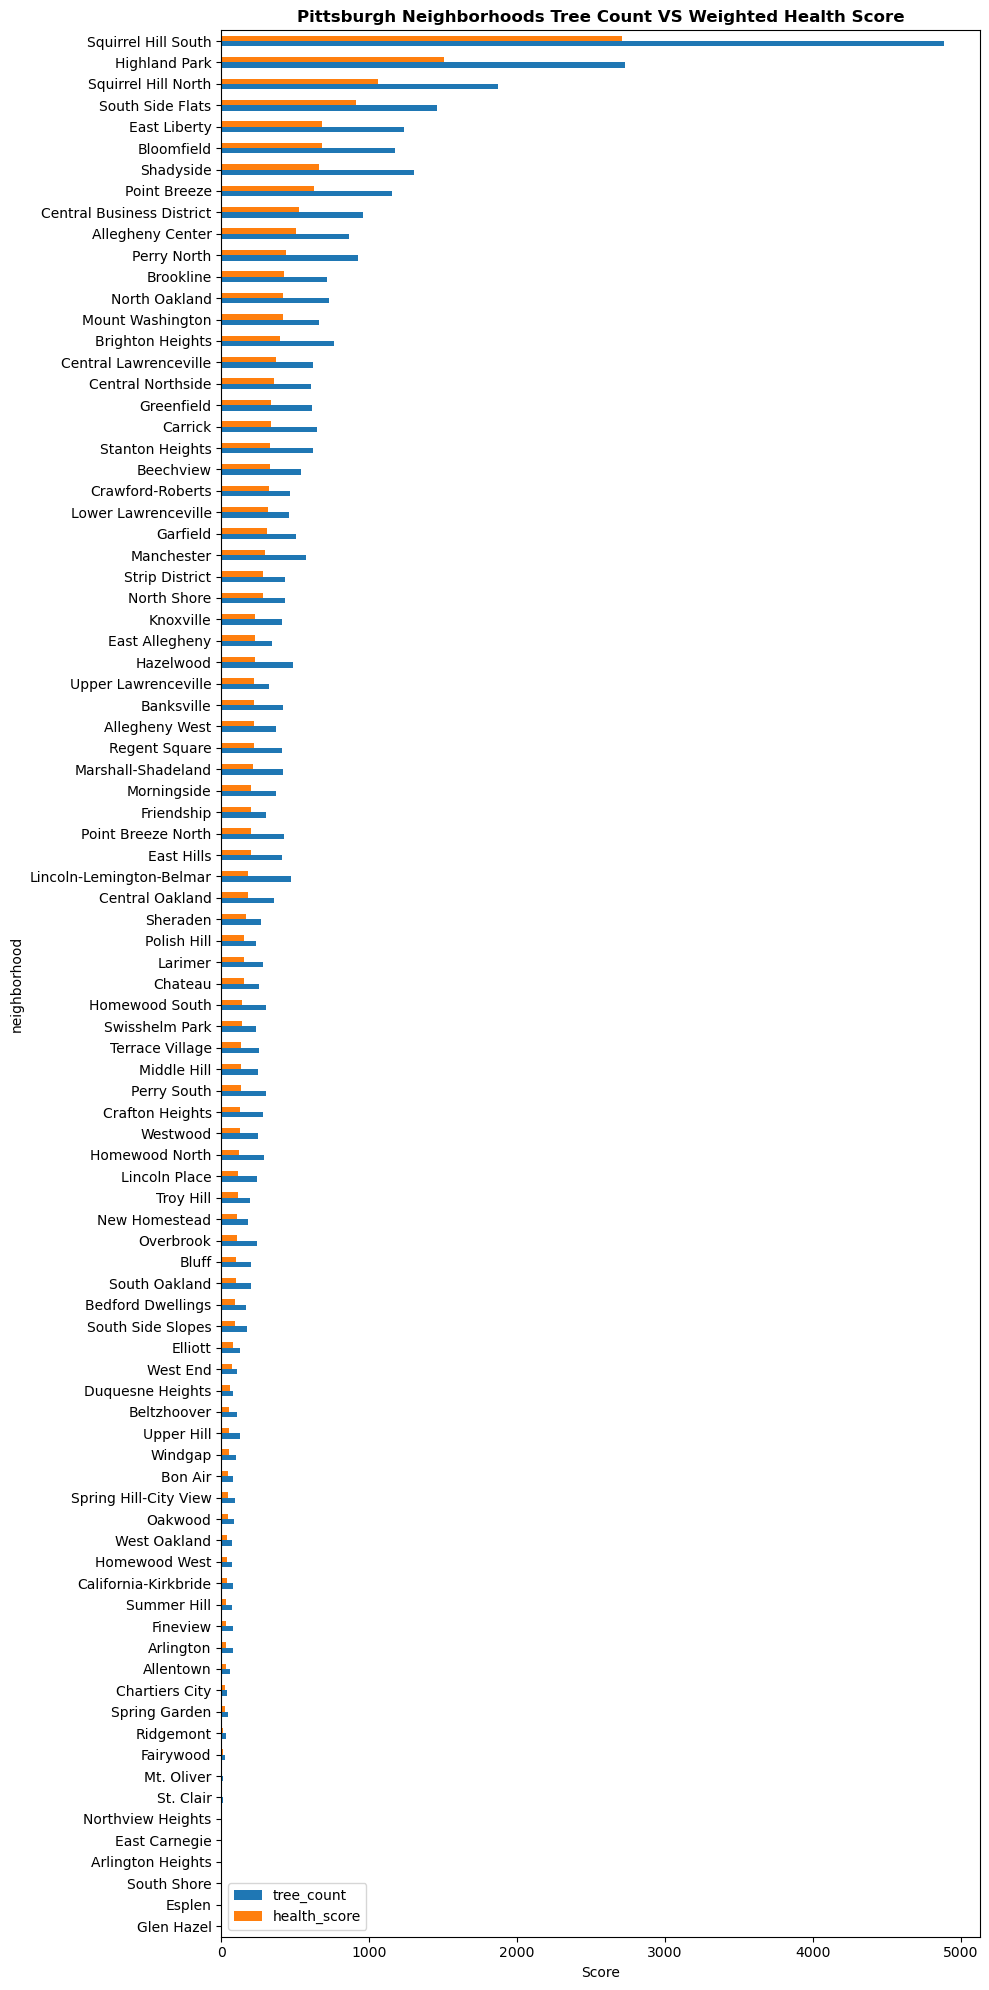

In [22]:
combined = health_score.merge(df.groupby('neighborhood').size().reset_index(name='tree_count'), on = 'neighborhood').sort_values('health_score')

combined.set_index('neighborhood')[['tree_count', 'health_score']].plot.barh(figsize=(10,20))
plt.xlabel('Score')
plt.title('Pittsburgh Neighborhoods Tree Count VS Weighted Health Score', fontweight = 'bold')
plt.tight_layout()
plt.show()

## Total benefit for each neighborhood

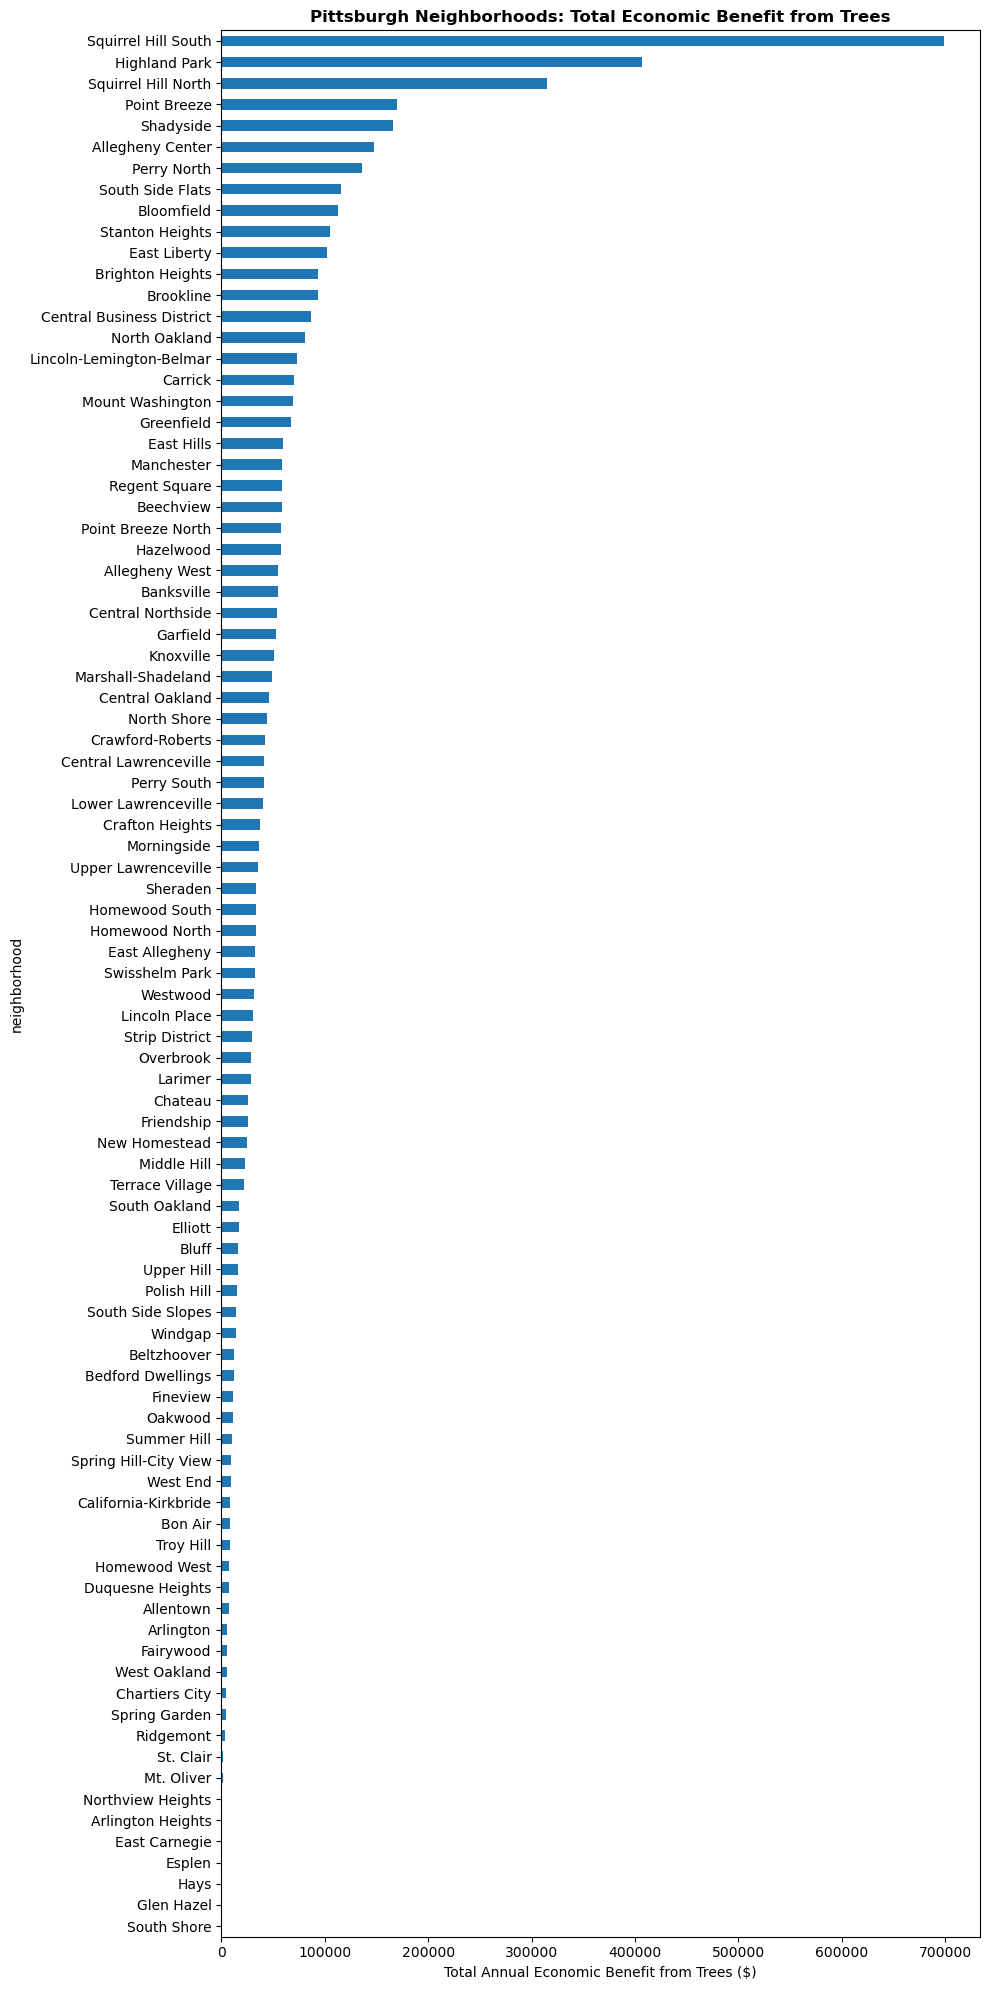

In [21]:
benefits.set_index('neighborhood').sort_values('total_benefit')['total_benefit'].plot.barh(figsize=(10,20))
plt.xlabel('Total Annual Economic Benefit from Trees ($)')
plt.title('Pittsburgh Neighborhoods: Total Economic Benefit from Trees', fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion
The overall best neighborhood of Pittsburgh through looking at the Tree dataset is Squirrel Hill South, scoring the highest in all three graphs of Tree Count, Tree Health and Total Economic Benefit.
### Tree count
The number of trees in each neighborhood. Generally, more is better.
### Tree Health Scores
Adjusts for three quality by scoreing each tree based on their condition. The highest score per tree is 1 and the lowest is 0.25.
### Economic Benefits
This is from the dataset's estimated annual dollar value for each tree's comtribution to air quality, storm water management, energy savings, CO2 reduction and property values. This metric helps to measure how the tree actually affects the neighborhood on an economic level.
### Limitations
This analysis does not account for the density of the trees which means that larger neighborhoods would have an advantage over smaller ones. Normalizing the neighborhoods area would make a much fairer comparison. This could be done by using tree density (trees per km squared for example) instead of number of trees.

Additionally, the data is from 2020, which means that changes in the recent 6 years would not be reflected in the data.